# Cuadrantes IPCC — Chile
## 16 regiones · CLP real (base 2013) · Método 3

**Fuente:** BCCh PIBR · INE Proyecciones · CCPI calculado en `IPCC_CHILE_M3.ipynb`

Eje Y: PIB per cápita real 2023 (CLP, base 2013 deflactado por IPC)

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from IPython.display import display
import warnings, os, unicodedata
warnings.filterwarnings('ignore')

BASE_FIGURAS = '/Users/diego/Desktop/MT/graficos/importantes'
BASE_DATA    = '/Users/diego/Desktop/MT/prototipo_ccpi/data'
BASE_DATOS   = '/Users/diego/Desktop/MT/Datos'
os.makedirs(BASE_FIGURAS, exist_ok=True)

COLOR_TIER  = {1: '#8B1A1A', 2: '#E07B39', 3: '#A9A9A9'}
MARKER_TIER = {1: '*', 2: 'D', 3: 'o'}
SIZE_TIER   = {1: 280, 2: 160, 3: 90}

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Serif', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.color': '#E8E0D8', 'grid.linewidth': 0.55,
})

IPC_CL = {
    2013: 1.000, 2014: 1.046, 2015: 1.085, 2016: 1.108,
    2017: 1.130, 2018: 1.160, 2019: 1.190, 2020: 1.204,
    2021: 1.268, 2022: 1.410, 2023: 1.476,
}

REGIONES_PIB_MAP = {
    'Region Metropolitana De Santiago':    'RM Santiago',
    'Region De Antofagasta':               'Antofagasta',
    'Region De Valparaiso':                'Valparaíso',
    'Region Del Biobio':                   'Biobío',
    'Region De La Araucania':              'Araucanía',
    'Region Del Maule':                    'Maule',
    "Region Del Libertador Gral. Bernardo O'higgins": "O'Higgins",
    'Region De Los Lagos':                 'Los Lagos',
    'Region De Coquimbo':                  'Coquimbo',
    'Region De Atacama':                   'Atacama',
    'Region de Nuble':                     'Ñuble',
    'Region De Los Rios':                  'Los Ríos',
    'Region De Arica Y Parinacota':        'Arica y Parinacota',
    'Region De Tarapaca':                  'Tarapacá',
    'Region De Aysen Del Gral. Carlos Ibanez Del Campo': 'Aysén',
    'Region De Magallanes Y De La Antartica Chilena':    'Magallanes',
}

AÑOS = list(range(2013, 2024))

def fix_enc(s):
    try:
        return s.encode('latin-1').decode('utf-8')
    except Exception:
        return s

def ascii_norm(s):
    return unicodedata.normalize('NFD', s).encode('ascii', 'ignore').decode('ascii').strip()

# ── 1. PIB regional total BCCh ────────────────────────────────────────────
with open(f'{BASE_DATOS}/PIBR_REGIONES.csv', encoding='latin-1') as f:
    raw_pib = f.read()

filas_pib = []
for line in raw_pib.strip().split('\n'):
    parts = [p.strip() for p in line.split(',')]
    if len(parts) < 13:
        continue
    try:
        vals = [float(parts[-(11-i)]) for i in range(11)]
    except ValueError:
        continue
    region_raw = fix_enc(parts[0])
    variable   = fix_enc(','.join(parts[1:-11]))
    if not variable.strip().startswith('PIB regional,'):
        continue
    region_norm = ascii_norm(region_raw)
    region_match = next(
        (v for k, v in REGIONES_PIB_MAP.items() if ascii_norm(k) == region_norm),
        None
    )
    if region_match is None:
        continue
    filas_pib.append({'region': region_match,
                      **{AÑOS[i]: vals[i] for i in range(11)}})

df_pib = pd.DataFrame(filas_pib)
print(f'PIB BCCh total regional: {len(df_pib)} regiones')

# ── 2. Población INE ──────────────────────────────────────────────────────
INE_FILE = (f'{BASE_DATOS}/ine_estimaciones-y-proyecciones-2002-2035'
            '_base-2017_reg_área_base.csv')
if not os.path.exists(INE_FILE):
    INE_FILE = (f'{BASE_DATOS}/ine_estimaciones-y-proyecciones-2002-2035'
                '_base-2017_reg_area_base.csv')

df_ine = pd.read_csv(INE_FILE, encoding='latin-1', sep=None, engine='python')
print(f'INE columnas: {list(df_ine.columns[:8])} ...')

# REGION es código entero 1-16; columnas de año = 'a2002'..'a2035'
REGION_CODE_MAP = {
    1: 'Tarapacá', 2: 'Antofagasta', 3: 'Atacama', 4: 'Coquimbo',
    5: 'Valparaíso', 6: "O'Higgins", 7: 'Maule', 8: 'Biobío',
    9: 'Araucanía', 10: 'Los Lagos', 11: 'Aysén', 12: 'Magallanes',
    13: 'RM Santiago', 14: 'Los Ríos', 15: 'Arica y Parinacota', 16: 'Ñuble',
}
pob_series = df_ine.groupby('REGION')['a2023'].sum()
POB = {REGION_CODE_MAP[int(code)]: int(val)
       for code, val in pob_series.items()
       if int(code) in REGION_CODE_MAP}
print(f'Población INE 2023: {len(POB)} regiones | ejemplo: {list(POB.items())[:3]}')

# ── 3. PIB pc real 2023 ───────────────────────────────────────────────────
registros = []
for _, row in df_pib.iterrows():
    nombre = row['region']
    pob23  = POB.get(nombre)
    pib23  = row.get(2023)
    if pob23 is None or pob23 <= 0:
        print(f'  Sin población 2023: {nombre}'); continue
    if pib23 is None or pd.isna(pib23):
        print(f'  Sin PIB 2023: {nombre}'); continue
    registros.append({'region': nombre,
                      'pib_pc_2023': float(pib23) * 1e9 / pob23 / IPC_CL[2023]})

df_pib_pc = pd.DataFrame(registros)
print(f'PIB pc real calculado: {len(df_pib_pc)} regiones')

# ── 4. Merge con CCPI ─────────────────────────────────────────────────────
df_ccpi = pd.read_csv(f'{BASE_DATA}/ccpi_chile_m3_2024.csv')
df_ccpi = df_ccpi[['region','tier','CCPI_M3','rank_M3','cuad_M3','tcac_pc']].copy()
df = df_ccpi.merge(df_pib_pc, on='region', how='left')
df['gdp_pc_abs'] = df['pib_pc_2023']
med_gdp      = float(df['gdp_pc_abs'].median())
med_ccpi_val = float(df['CCPI_M3'].median())

print(f'\nMediana CCPI_M3 : {med_ccpi_val:.3f}')
print(f'Mediana PIB pc  : ${med_gdp/1e6:.2f}M CLP (base 2013)')
display(df[['region','tier','CCPI_M3','rank_M3','gdp_pc_abs','cuad_M3']]
        .assign(M_CLP=lambda x: (x['gdp_pc_abs']/1e6).round(2))
        .sort_values('rank_M3'))

LEG_HANDLES = [
    Line2D([0],[0], marker='*', color='w', markerfacecolor=COLOR_TIER[1],
           markersize=13, label='T1 — RM Santiago'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor=COLOR_TIER[2],
           markersize=9,  label='T2 — Ciudad secundaria'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_TIER[3],
           markersize=7,  label='T3 — Resto de regiones'),
]


PIB BCCh total regional: 16 regiones
INE columnas: ['REGION', 'AREA', 'SEXO', 'EDAD', 'a2002', 'a2003', 'a2004', 'a2005'] ...
Población INE 2023: 16 regiones | ejemplo: [('Tarapacá', 401588), ('Antofagasta', 714142), ('Atacama', 319048)]
PIB pc real calculado: 16 regiones

Mediana CCPI_M3 : 0.485
Mediana PIB pc  : $7.10M CLP (base 2013)


,region,tier,CCPI_M3,rank_M3,gdp_pc_abs,cuad_M3,M_CLP
14,Tarapacá,3,0.550534,1,1.331468e+07,Motor consolidado,13.31
15,Ñuble,3,0.527588,2,5.355453e+06,Motor consolidado,5.36
6,Maule,3,0.523590,3,6.030059e+06,Motor consolidado,6.03
13,Los Ríos,3,0.508176,4,5.867903e+06,Motor consolidado,5.87
9,Los Lagos,3,0.505209,5,7.042090e+06,Motor consolidado,7.04
7,Biobío,2,0.501401,6,6.741572e+06,Capital estancada,6.74
3,Coquimbo,3,0.493037,7,7.151581e+06,Capital estancada,7.15
8,Araucanía,3,0.487268,8,5.102125e+06,Motor consolidado,5.10
4,Valparaíso,2,0.483143,9,6.831312e+06,Rezagada,6.83
11,Magallanes,3,0.479860,10,9.258017e+06,Rezagada,9.26


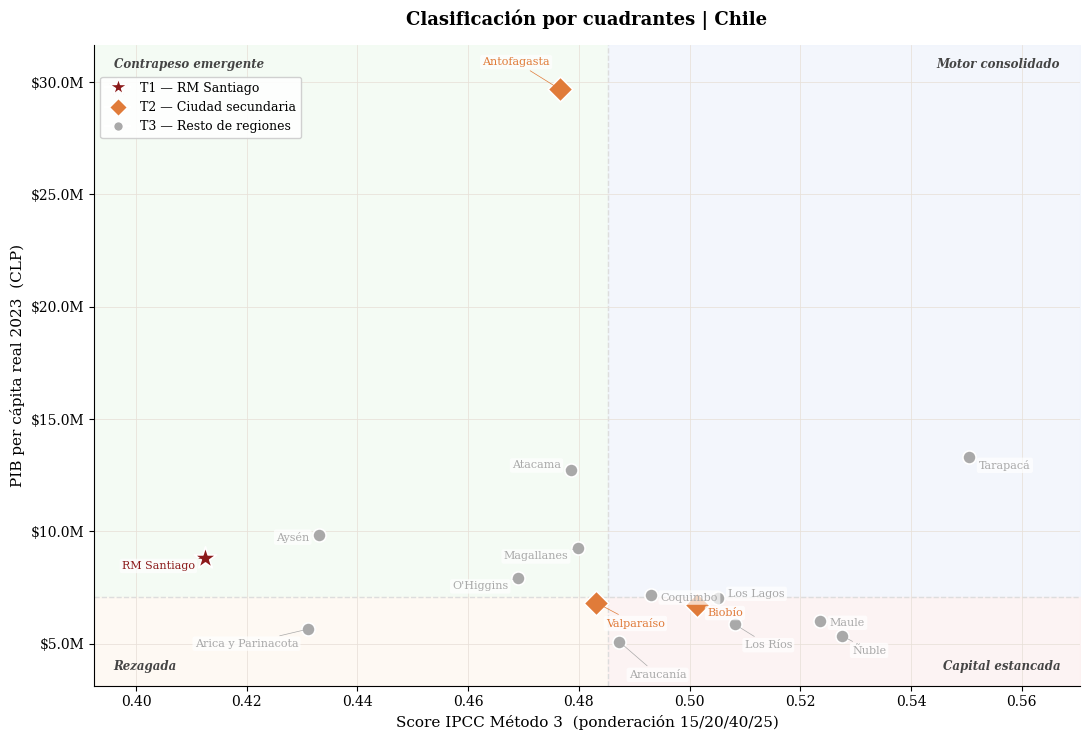

✓ Figura guardada → /Users/diego/Desktop/MT/graficos/importantes/F1d_cuadrante_pib_pc_abs_CL_2024.png
  Mediana CCPI_M3 : 0.485
  Mediana PIB pc  : $7.10M CLP (base 2013)


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# F1d — Cuadrantes IPCC · Chile · PIB pc real absoluto 2023 (CLP base 2013)
# ══════════════════════════════════════════════════════════════════════════════
med_ccpi = float(df['CCPI_M3'].median())
med_pib  = float(df['gdp_pc_abs'].median())

_ys = df['gdp_pc_abs'].values
xmin = df['CCPI_M3'].min() - 0.02
xmax = df['CCPI_M3'].max() + 0.02
pad_y = (_ys.max() - _ys.min()) * 0.08
ymin = _ys.min() - pad_y
ymax = _ys.max() + pad_y

fig, ax = plt.subplots(figsize=(11, 7.5))

for (x0, x1, y0, y1), color in [
    ((xmin, med_ccpi, med_pib, ymax), '#F2FBF2'),
    ((med_ccpi, xmax, med_pib, ymax), '#F0F4FC'),
    ((xmin, med_ccpi, ymin, med_pib), '#FEF8F0'),
    ((med_ccpi, xmax, ymin, med_pib), '#FCF0F0'),
]:
    ax.fill_betweenx([y0, y1], x0, x1, color=color, alpha=0.80, zorder=0)

ax.axvline(med_ccpi, color='#DDDDDD', lw=1, ls='--', zorder=1)
ax.axhline(med_pib,  color='#DDDDDD', lw=1, ls='--', zorder=1)

kw_q = dict(fontsize=8.5, color='#444444', fontstyle='italic',
            fontweight='semibold', fontfamily='DejaVu Serif',
            transform=ax.transAxes)
ax.text(0.98, 0.98, 'Motor consolidado',    ha='right', va='top',    **kw_q)
ax.text(0.02, 0.98, 'Contrapeso emergente', ha='left',  va='top',    **kw_q)
ax.text(0.98, 0.02, 'Capital estancada',    ha='right', va='bottom', **kw_q)
ax.text(0.02, 0.02, 'Rezagada',             ha='left',  va='bottom', **kw_q)

for _, row in df.iterrows():
    t = int(row['tier'])
    ax.scatter(float(row['CCPI_M3']), float(row['gdp_pc_abs']),
               color=COLOR_TIER[t], s=SIZE_TIER[t], marker=MARKER_TIER[t],
               edgecolors='white', linewidth=1.2, zorder=5)

MIN_SEP = 9
cx_mid = (df['CCPI_M3'].min() + df['CCPI_M3'].max()) / 2
cy_mid = (_ys.min() + _ys.max()) / 2
rng_x  = df['CCPI_M3'].max() - df['CCPI_M3'].min() + 1e-9
anns = []
for _, row in df.iterrows():
    t  = int(row['tier'])
    cx = float(row['CCPI_M3'])
    cy = float(row['gdp_pc_abs'])
    dx = +7 if cx >= cx_mid else -7
    dy = +6 if cy >= cy_mid else -6
    anns.append({'label': row['region'], 'cx': cx, 'cy': cy,
                 'dx': dx, 'dy': dy, 'color': COLOR_TIER[t]})

for _ in range(30):
    for i in range(len(anns)):
        for j in range(i + 1, len(anns)):
            a, b = anns[i], anns[j]
            if abs(a['cx'] - b['cx']) < rng_x * 0.06:
                if abs(a['dy'] - b['dy']) < MIN_SEP:
                    sep = MIN_SEP * 0.5
                    if a['cy'] >= b['cy']: a['dy'] += sep; b['dy'] -= sep
                    else:                  a['dy'] -= sep; b['dy'] += sep

for ann in anns:
    ax.annotate(ann['label'],
        xy=(ann['cx'], ann['cy']),
        xytext=(ann['dx'], ann['dy']),
        textcoords='offset points',
        fontsize=8, fontfamily='DejaVu Serif', color=ann['color'],
        va='center', ha='left' if ann['dx'] >= 0 else 'right',
        arrowprops=dict(arrowstyle='-', color=ann['color'],
                        lw=0.5, connectionstyle='arc3,rad=0.0'),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7),
        zorder=6)

ax.legend(handles=LEG_HANDLES, fontsize=9, framealpha=0.9,
            loc='upper left', frameon=True,
            bbox_to_anchor=(0.0, 0.96))
ax.set_xlabel('Score IPCC Método 3  (ponderación 15/20/40/25)',
              fontfamily='DejaVu Serif', fontsize=11)
ax.set_ylabel('PIB per cápita real 2023  (CLP)',
              fontfamily='DejaVu Serif', fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M'))
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title(
    'Clasificación por cuadrantes | Chile',
    fontfamily='DejaVu Serif', fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
ruta = f'{BASE_FIGURAS}/F1d_cuadrante_pib_pc_abs_CL_2024.png'
fig.savefig(ruta, dpi=300, bbox_inches='tight', facecolor='white')
display(fig)
plt.close()
print(f'✓ Figura guardada → {ruta}')
print(f'  Mediana CCPI_M3 : {med_ccpi:.3f}')
print(f'  Mediana PIB pc  : ${med_pib/1e6:.2f}M CLP (base 2013)')


In [3]:
# RESUMEN
print()
print('╔' + '═'*72 + '╗')
print('║  IPCC · CHILE · MÉTODO 3 · 16 regiones' + ' '*32 + '║')
print('╠' + '═'*72 + '╣')
print(f'  {"Rank":>4}  {"Tier":<5}  {"Región":<22}  {"CCPI_M3":>8}  {"PIB pc real 2023":>18}  Cuadrante')
print('  ' + '─'*72)
for _, row in df.sort_values('rank_M3').iterrows():
    print(f'  #{int(row["rank_M3"]):>3}  T{int(row["tier"])}    '
          f'{row["region"]:<22}  {row["CCPI_M3"]:>8.3f}  '
          f'${row["gdp_pc_abs"]/1e6:>12.2f}M CLP  '
          f'{row["cuad_M3"]}')
print('╚' + '═'*72 + '╝')



╔════════════════════════════════════════════════════════════════════════╗
║  IPCC · CHILE · MÉTODO 3 · 16 regiones                                ║
╠════════════════════════════════════════════════════════════════════════╣
  Rank  Tier   Región                   CCPI_M3    PIB pc real 2023  Cuadrante
  ────────────────────────────────────────────────────────────────────────
  #  1  T3    Tarapacá                   0.551  $       13.31M CLP  Motor consolidado
  #  2  T3    Ñuble                      0.528  $        5.36M CLP  Motor consolidado
  #  3  T3    Maule                      0.524  $        6.03M CLP  Motor consolidado
  #  4  T3    Los Ríos                   0.508  $        5.87M CLP  Motor consolidado
  #  5  T3    Los Lagos                  0.505  $        7.04M CLP  Motor consolidado
  #  6  T2    Biobío                     0.501  $        6.74M CLP  Capital estancada
  #  7  T3    Coquimbo                   0.493  $        7.15M CLP  Capital estancada
  #  8  T3    Arauc